In [1]:
import sys
import subprocess
import importlib.util
# Check if symfit is already installed
if importlib.util.find_spec("symfit") is None:
    print("Installing symfit...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "symfit"])
    print("SymFit installed successfully!")
else:
    print("SymFit is already installed.")

# Import symfit and verify installation
import symfit
print(f"SymFit version: {symfit.__version__}")

import pandas as pd
import numpy as np
from symfit import parameters,variables,Fit,D,ODEModel
import matplotlib.pyplot as plt

p215 = pd.read_csv('0p1mM-LP1_10-eq-MAD.csv', \
                  sep=',')
p215.head()

SymFit is already installed.
SymFit version: 0.5.6


,time-h,linear-frac,1-arm-frac,cycle-frac,2-arm-frac,LP,MP,CP,MPM
0,0.000000,1.000,0.000,0.000,0.000,0.000100,0.000000,0.000000,0.000000
1,0.038333,0.805,0.153,0.015,0.027,0.000081,0.000015,0.000002,0.000003
2,0.150000,0.169,0.437,0.074,0.320,0.000017,0.000044,0.000007,0.000032
3,0.283333,0.027,0.254,0.078,0.641,0.000003,0.000025,0.000008,0.000064
4,0.420000,0.014,0.145,0.120,0.721,0.000001,0.000014,0.000012,0.000072


In [2]:
import numpy as np
from symfit import parameters,variables,Fit,D,ODEModel, Parameter
import matplotlib.pyplot as plt

%matplotlib nbagg
%matplotlib inline 

t, p, m, pm, cp, ol = variables('t, p, m, pm, cp, ol')
k1 = Parameter('k1', value=4*60*60) # min=1*60, max=2*60 
k2 = Parameter('k2', value=0.00019*60*60) #, min=0.009*60, max=0.045*60)
k3 = Parameter('k3', value=1.2*60*60) #, min=0.3*60, max=0.8*60)
#k1 = 1.9*60
#k2 = 0.022*60
#k3.value = 0.5*60


t_data=np.array(p215["time-h"], dtype=np.float64)
p_data=np.array(p215.LP, dtype=np.float64)
pm_data=np.array(p215.MP, dtype=np.float64)
cp_data=np.array(p215.CP, dtype=np.float64)
ol_data=np.array(p215.MPM, dtype=np.float64)

t0=0.0
p0=0.0001
m0=0.001
pm0=0.0
cp0=0.0
ol0=0.0

Derivative(cp, t; k1, k2, k3) = k2*pm
Derivative(m, t; k1, k2, k3) = -k1*m*p - k3*m*pm
Derivative(ol, t; k1, k2, k3) = k3*m*pm
Derivative(p, t; k1, k2, k3) = -k1*m*p
Derivative(pm, t; k1, k2, k3) = k1*m*p - k2*pm - k3*m*pm

Parameter Value        Standard Deviation
k1        1.440000e+04 2.668144e+03
k2        6.840000e-01 1.189599e-01
k3        4.320000e+03 5.485481e+02
Status message         Optimization terminated successfully.
Number of iterations   0
Objective              <symfit.core.objectives.LeastSquares object at 0x317b58690>
Minimizer              <symfit.core.minimizers.BFGS object at 0x317b59090>

Goodness of fit qualifiers:
chi_squared            2.3979164367579998e-09
objective_value        1.1989582183789999e-09
r_squared              0.9239230717652722


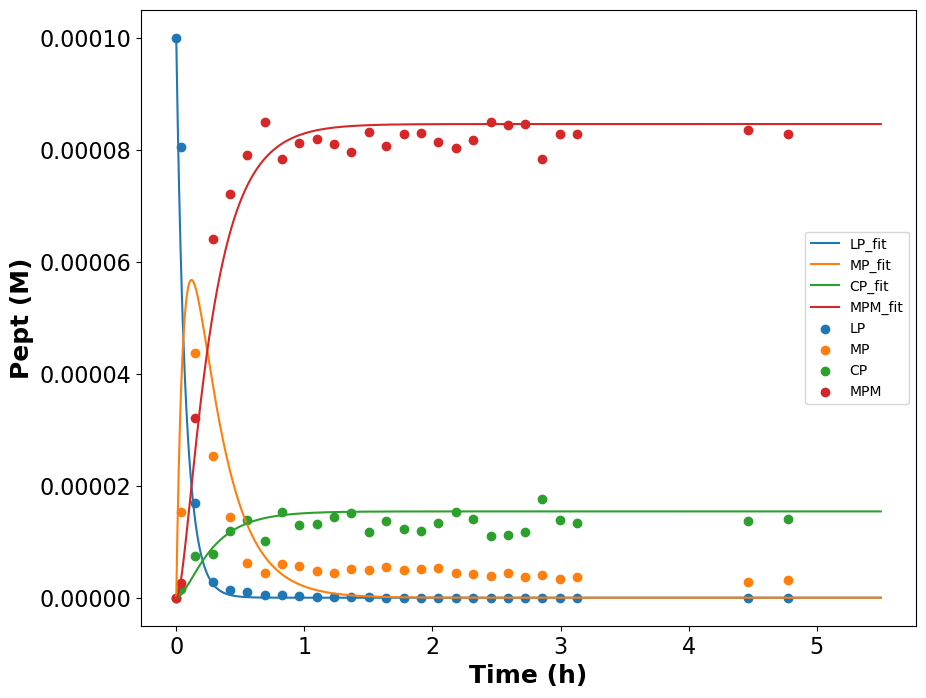

In [4]:
# Compatibility fix for the numpy.product issue
import numpy as np

# Add this compatibility function to handle the missing numpy.product
if not hasattr(np, 'product'):
    np.product = np.prod  # Create an alias for np.prod as np.product


model_dict = {D(p, t): -k1*p*m, \
              D(pm, t): k1*p*m - k2*pm - k3*pm*m, \
              D(cp, t): k2*pm, \
              D(ol, t): k3*pm*m, \
              D(m, t): -k1*p*m - k3*pm*m}


ode_model = ODEModel(model_dict, initial={t: t0, p: p0, m: m0, pm: pm0, cp: cp0, ol:ol0})
print (ode_model)
fit = Fit(ode_model, t=t_data, p=p_data, pm=pm_data, cp=cp_data, ol=ol_data, m=None)
fit_result = fit.execute()
print (fit_result)

tvec = np.linspace(0.0, 5.5, 10000)
cp, m, ol, p, pm = ode_model(t=tvec, **fit_result.params)

plt.figure(figsize=(10, 8))
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.plot(tvec, p, label='LP_fit')
#plt.plot(tvec, m, label='mad_fit')
plt.plot(tvec, pm, label='MP_fit')
plt.plot(tvec, cp, label='CP_fit')
plt.plot(tvec, ol, label='MPM_fit')

plt.scatter(t_data, p_data, label='LP')
plt.scatter(t_data, pm_data, label='MP')
plt.scatter(t_data, cp_data, label='CP')
plt.scatter(t_data, ol_data, label='MPM')
#plt.ylim(-0.0001,0.001)
plt.xlabel('Time (h)', fontsize=18, fontweight = 'bold')
plt.ylabel('Pept (M)', fontsize=18, fontweight = 'bold')
plt.legend(loc='best')
plt.show()

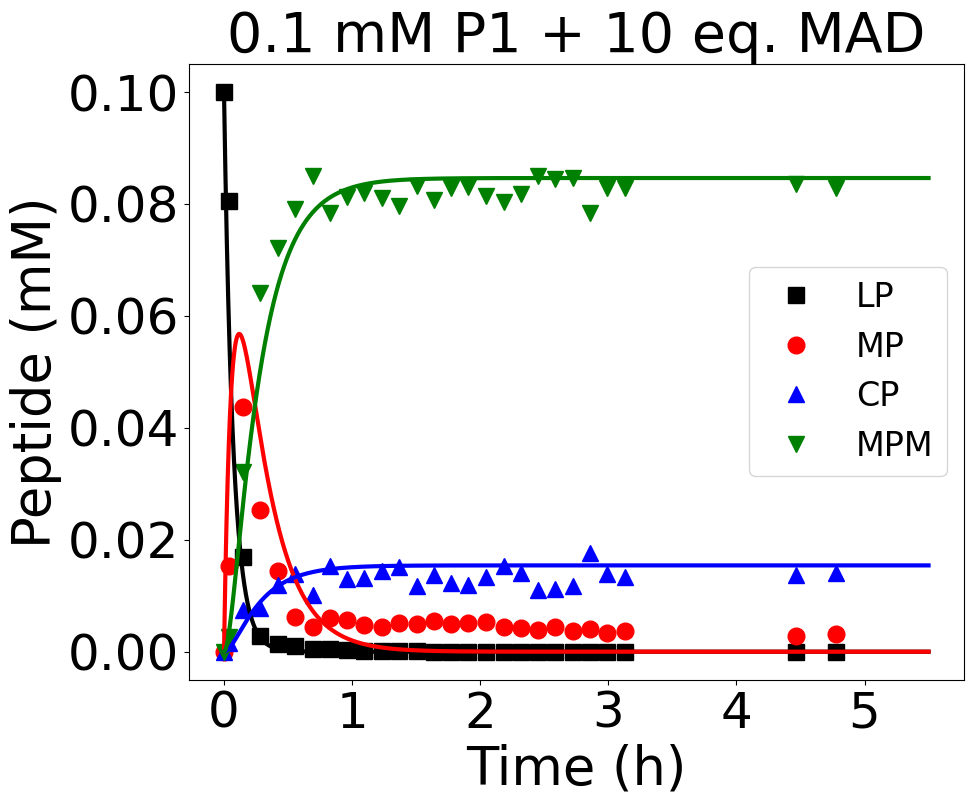

In [5]:
fig, ax = plt.subplots(1,1, figsize=(10,8))

ax.plot(t_data, p_data*1000, marker='s', markersize=12, ls='', color='black', label='LP')
ax.plot(t_data, pm_data*1000, marker='o', ls='', markersize=12, color='red', label='MP')
ax.plot(t_data, cp_data*1000, marker='^', markersize=12, ls='', color='blue', label='CP')
ax.plot(t_data, ol_data*1000, marker='v', markersize=12, ls='', color='green', label='MPM')
ax.plot(tvec, p*1000, 'black', tvec, pm*1000, 'r', tvec, cp*1000, 'b', tvec, ol*1000, 'g', linewidth = 3) #tvec, ol*1000, 'g', 

ax.set_xlabel('Time (h)', fontsize=38, fontweight = 'normal')
ax.set_ylabel('Peptide (mM)', fontsize=38, fontweight = 'normal')
plt.xticks(fontsize=36, fontweight = 'normal')
plt.yticks(fontsize=36, fontweight = 'normal')
ax.set_title('0.1 mM P1 + 10 eq. MAD', fontsize=40, fontweight = 'normal')
ax.legend(loc=0,fontsize=24)

#from matplotlib import ticker
#formatter = ticker.ScalarFormatter(useOffset=True)
#formatter.set_scientific(True) 
#formatter.set_powerlimits((-1,1)) 
#ax.yaxis.set_major_formatter(formatter)

plt.show()
fig.savefig('fit-0p1mM-P1-10eqMAD.svg', dpi=300, transparent=True)

In [6]:
def kh(a):
    return a/3600
def ks(b):
    return b*3600

In [ ]:
kh(15770)

In [ ]:
ks(0.04)